In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from xgboost import XGBRegressor

import joblib

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    "../processed_data/forecasting_features.csv"
)

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,store,item,sales,year,month,quarter,day,day_of_week,day_of_year,week_of_year,is_weekend,lag_7,lag_14,lag_30,lag_90,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30
0,2013-04-01,1,1,11,2013,4,2,1,0,91,14,0,13.0,11.0,13.0,13.0,15.571429,15.400000,3.359422,3.596934
1,2013-04-02,1,1,19,2013,4,2,2,1,92,14,0,16.0,19.0,20.0,11.0,15.285714,15.333333,3.683942,3.660915
2,2013-04-03,1,1,24,2013,4,2,3,2,93,14,0,11.0,14.0,14.0,14.0,15.714286,15.300000,3.946065,3.621297
3,2013-04-04,1,1,18,2013,4,2,4,3,94,14,0,13.0,17.0,13.0,13.0,17.571429,15.633333,4.391550,3.943422
4,2013-04-05,1,1,19,2013,4,2,5,4,95,14,0,17.0,21.0,17.0,10.0,18.285714,15.800000,3.903600,3.933937


In [3]:
train = df[df["date"] < "2017-01-01"]

test = df[df["date"] >= "2017-01-01"]

In [4]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (685500, 20)
Test Shape: (182500, 20)


In [5]:
baseline_pred = test["lag_7"]

In [8]:
baseline_mae = mean_absolute_error(
    test["sales"],
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test["sales"],
        baseline_pred
    )
)

print("Baseine MAE:", baseline_mae)
print("Baseine RMSE:", baseline_rmse)

Baseine MAE: 8.841452054794521
Baseine RMSE: 11.596704066478521


In [11]:
features = [
    "store",
    "item",

    "year",
    "month",
    "quarter",
    "day",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "is_weekend",

    "lag_7",
    "lag_14",
    "lag_30",
    "lag_90",

    "rolling_mean_7",
    "rolling_mean_30",
    
    "rolling_std_7",
    "rolling_std_30",
]

In [16]:
x_train = train[features]
y_train = train["sales"]

x_test = test[features]
y_test = test["sales"]

In [17]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [18]:
model.fit(
    x_train,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [19]:
predictions = model.predict(
    x_test
)

In [31]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("XGBoost MAE:", mae)
print("XGBoost RMSE:", rmse)

XGBoost MAE: 6.090098857879639
XGBoost RMSE: 7.91016203703492


In [32]:
improvement = (
    (baseline_rmse - rmse) / baseline_rmse
) * 100

print(
    f"Improvement over baseline: {improvement:.2f}%"
)

Improvement over baseline: 31.79%


In [33]:
importance = pd.DataFrame({
    "features": features,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(10)

,features,importance
14,rolling_mean_7,0.515109
10,lag_7,0.200780
15,rolling_mean_30,0.083690
9,is_weekend,0.083102
6,day_of_week,0.045362
11,lag_14,0.044809
3,month,0.008157
8,week_of_year,0.005018
5,day,0.003608
7,day_of_year,0.003348


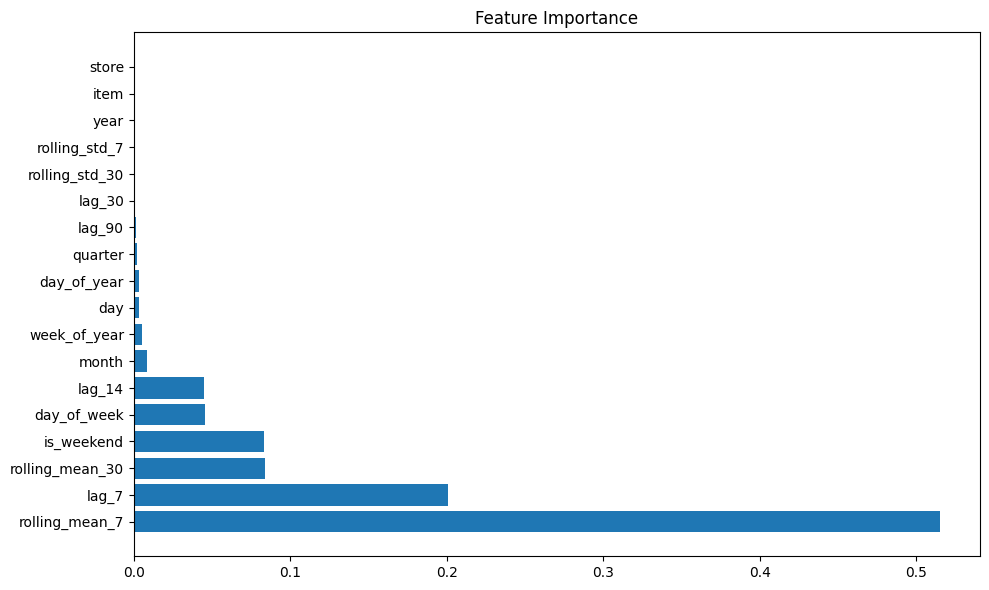

In [34]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["features"],
    importance["importance"]
)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

In [35]:
joblib.dump(
    model,
    "../models/xgboost_forecasting_model.pkl"
)

['../models/xgboost_forecasting_model.pkl']

In [36]:
loaded_model = joblib.load(
    "../models/xgboost_forecasting_model.pkl"
)

print(type(loaded_model))

<class 'xgboost.sklearn.XGBRegressor'>
